# Clustering Evaluation


Confronto tra run di clustering già **prodotte** (`fine_tuning: false`) - il tuning è già
stato fatto altrove, qui si legge il risultato.

### Scopo

Questo notebook non sceglie `k` né un metodo: quella decisione è già stata presa in fase
di tuning (`clustering.py --fine_tuning true`, letta a occhio da chi lo ha lanciato -
`code_standards.md` §0, nessuna selezione automatica). Qui si valutano le run già
prodotte, in due modi:

1. **Metriche intrinseche** - quanto è compatta/separata una singola run: 
      - Silhouette,
      - Davies-Bouldin, 
      - Calinski-Harabasz 
      - il Dunn Index
      - quando il metodo li espone, AIC/BIC/Inerzia.
2. **Metriche di confronto diretto** - quanto si assomigliano due o più run: 
      - ARI e NMI
      - una match matrix 
      - Subsampling Stability Index 



In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix

# Repo root isn't on sys.path when this notebook runs with cwd=notebooks/post-results_analysis/ -
# same fix as temp/*/run_prototype.py, needed here for the `from src...` imports below.
NOTEBOOK_REPO_ROOT = Path.cwd().resolve().parents[1]
if str(NOTEBOOK_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_REPO_ROOT))

from src.analysis.clustering_tuning import compute_clustering_metrics, dunn_index, run_clustering_tuning_sweep
from src.analysis.consensus_clustering import subsampling_stability_index
from src.utils.artifacts import load_matrix, read_run_params, save_matrix

sns.set_theme(style="whitegrid")


## 1. Dataset sintetico e run di clustering (stand-in)

Da questi blob produciamo 4 run stand-in, scelte per confrontare sia lo stesso metodo a
`k` diversi sia metodi diversi allo stesso `k`: `kmeans_k4` (il `k` corretto), `kmeans_k6`
(`k` sovra-specificato), `agglomerative_k4` (metodo diverso, stesso `k`) e `gmm_k4` (per
avere anche AIC/BIC in tabella).


In [2]:
X, _true_labels = make_blobs(n_samples=300, centers=4, n_features=2, cluster_std=2.2, random_state=42)
subject_ids = [f"sub-SYNTH{i:04d}" for i in range(X.shape[0])]
print(f"dataset sintetico: {X.shape}")


dataset sintetico: (300, 2)


In [3]:
# (nome_run, metodo, base_params, tuning_grid a 1 valore) - un solo fit per run,
# run_clustering_tuning_sweep calcola già tutte le metriche (produzione/tuning, non reimplementate).
RUN_SPECS = [
    ("kmeans_k4", "kmeans", {"random_state": 0, "n_init": "auto"}, {"n_clusters": [4]}),
    ("kmeans_k6", "kmeans", {"random_state": 0, "n_init": "auto"}, {"n_clusters": [6]}),
    ("agglomerative_k4", "agglomerative", {"linkage": "ward"}, {"n_clusters": [4]}),
    ("gmm_k4", "gmm", {"random_state": 0}, {"n_components": [4]}),
]

OUTPUT_ROOT = NOTEBOOK_REPO_ROOT / "results/lesion/clustering/production"
SESSION_NAME = "notebook_synthetic_demo"  # nome esplicito, non ambiguo con una vera run


Per ogni configurazione eseguiamo il fit e calcoliamo le metriche con
`run_clustering_tuning_sweep` — lo stesso codice usato in produzione/tuning, non una
reimplementazione. Le etichette risultanti diventano la colonna `cluster_label` di
`metadata.csv`, la stessa convenzione che usa `clustering.py` (`docs/dev/models.md`,
"Where cluster labels live"), e vengono scritte su disco con `save_matrix`.

`extra_metrics` (inertia/bic/aic) non fa parte del contratto ufficiale degli artifact: la
scriviamo comunque in `config.md` come riga `Extra metrics: {...}` (una convenzione di
questo notebook) così la tabella delle metriche intrinseche può rileggerla dopo il
round-trip su disco, invece di tenerla solo in memoria.


In [4]:
GENERIC_METRIC_KEYS = {"silhouette", "calinski_harabasz", "davies_bouldin", "noise_fraction"}  # sempre presenti


def write_synthetic_run(name: str, method: str, base_params: dict, tuning_grid: dict) -> Path:
    results, labels_by_combo = run_clustering_tuning_sweep(method, X, base_params, tuning_grid)
    assert len(results) == 1, "tuning_grid a un solo valore deve produrre esattamente 1 riga"
    row = results.iloc[0].to_dict()
    (combo,) = labels_by_combo.keys()
    labels = labels_by_combo[combo]

    resolved_params = {**base_params, **dict(zip(tuning_grid.keys(), combo))}
    extra_metrics = {k: float(v) for k, v in row.items() if k not in tuning_grid and k not in GENERIC_METRIC_KEYS}

    metadata = pd.DataFrame({"subject_id": subject_ids, "cluster_label": labels})
    readme_lines = [
        f"# NEMESIS clustering (synthetic evaluation demo) — {method}",
        "",
        "Synthetic stand-in run (make_blobs) for notebooks/post-results_analysis/clustering_evaluation.ipynb",
        "(no real results/lesion/clustering production run existed yet - see docs/guides/evaluation.md).",
        "",
        f"Params used: {json.dumps(resolved_params)}",
        f"Extra metrics: {json.dumps(extra_metrics)}",
    ]

    output_dir = OUTPUT_ROOT / method / f"{SESSION_NAME}_{name}"
    save_matrix(output_dir, X, metadata, readme_lines, overwrite=True)
    return output_dir


run_dirs = {name: write_synthetic_run(name, method, base_params, tuning_grid) for name, method, base_params, tuning_grid in RUN_SPECS}
run_dirs


{'kmeans_k4': PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/results/lesion/clustering/production/kmeans/notebook_synthetic_demo_kmeans_k4'),
 'kmeans_k6': PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/results/lesion/clustering/production/kmeans/notebook_synthetic_demo_kmeans_k6'),
 'agglomerative_k4': PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/results/lesion/clustering/production/agglomerative/notebook_synthetic_demo_agglomerative_k4'),
 'gmm_k4': PosixPath('/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/results/lesion/clustering/production/gmm/notebook_synthetic_demo_gmm_k4')}

### Caricamento tramite il contratto reale degli artifact

Da qui in poi ogni run viene letta solo da disco, mai dalla memoria: `load_matrix` (lo
stesso loader di `clustering.py`/`embedding_app.py`) per la matrice e i metadati,
`read_run_params` per i parametri risolti, e un piccolo parser locale per la riga
`Extra metrics:` di `config.md`.


In [5]:
def read_extra_metrics(run_dir: Path) -> dict:
    """Riga 'Extra metrics: {...}' di config.md - convenzione di questo notebook, non del
    contratto artifacts.py."""
    for line in (run_dir / "config.md").read_text().splitlines():
        if line.startswith("Extra metrics: "):
            return json.loads(line[len("Extra metrics: ") :])
    raise ValueError(f"{run_dir}/config.md has no 'Extra metrics:' line")


runs = {}
for name, input_dir in run_dirs.items():
    run_X, run_metadata, _extra_arrays = load_matrix(input_dir)
    method = input_dir.parent.name  # OUTPUT_ROOT/<method>/<session_name>/, see write_synthetic_run
    runs[name] = {
        "input_dir": input_dir,
        "method": method,
        "X": run_X,
        "metadata": run_metadata,
        "labels": run_metadata["cluster_label"].to_numpy(),
        "params": read_run_params(input_dir),
        "extra_metrics": read_extra_metrics(input_dir),
    }

for name, run in runs.items():
    print(f"{name} ({run['method']}): {run['X'].shape[0]} soggetti, {len(np.unique(run['labels']))} cluster, params={run['params']}")


kmeans_k4 (kmeans): 300 soggetti, 4 cluster, params={'random_state': 0, 'n_init': 'auto', 'n_clusters': 4}
kmeans_k6 (kmeans): 300 soggetti, 6 cluster, params={'random_state': 0, 'n_init': 'auto', 'n_clusters': 6}
agglomerative_k4 (agglomerative): 300 soggetti, 4 cluster, params={'linkage': 'ward', 'n_clusters': 4}
gmm_k4 (gmm): 300 soggetti, 4 cluster, params={'random_state': 0, 'n_components': 4}


## 2. Metriche intrinseche

Una riga per run: Silhouette, Calinski-Harabasz, Davies-Bouldin e noise_fraction (da
`compute_clustering_metrics`), il Dunn Index, e - quando il metodo li espone - `inertia`
(kmeans) o `bic`/`aic` (gmm). Nessuna run ha entrambi gli extra; dove mancano compare `NaN`.


In [6]:
intrinsic_rows = []
for name, run in runs.items():
    metrics = compute_clustering_metrics(run["X"], run["labels"])
    metrics["dunn"] = dunn_index(run["X"], run["labels"])
    metrics.update(run["extra_metrics"])
    intrinsic_rows.append({"run": name, **metrics})

intrinsic_table = pd.DataFrame(intrinsic_rows).set_index("run")
intrinsic_table


,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,dunn,inertia,bic,aic
run,,,,,,,,
kmeans_k4,0.568524,729.690925,0.613435,0.0,0.049674,2614.945130,NaN,NaN
kmeans_k6,0.432646,549.636498,0.961303,0.0,0.028794,2121.641731,NaN,NaN
agglomerative_k4,0.549526,675.519148,0.613831,0.0,0.046818,NaN,NaN,NaN
gmm_k4,0.567081,727.936968,0.616353,0.0,0.020993,NaN,3517.578585,3432.391588


**Lettura**: `kmeans_k6` dovrebbe risultare peggiore di `kmeans_k4` su Silhouette, Dunn e
Davies-Bouldin, dato che il `k` è sovra-specificato rispetto ai 4 blob veri — se così non
fosse, varrebbe la pena capire perché prima di fidarsi delle altre run. AIC/BIC di
`gmm_k4` non sono sulla stessa scala di Silhouette/Dunn/CH/DB: servono a confrontare GMM
con *altri* GMM, non con k-means o gerarchico.


## 3. Metriche di confronto diretto: ARI / NMI

Calcoliamo Adjusted Rand Index e Normalized Mutual Information tra ogni coppia di run
(`sklearn.metrics`, nessun calcolo nuovo). Prima di confrontare due run verifichiamo
esplicitamente che condividano lo stesso ordine di `subject_id` — un'assunzione che vale
per questo dataset sintetico ma non va data per scontata con run di produzione reali, che
potrebbero coprire soggetti diversi.


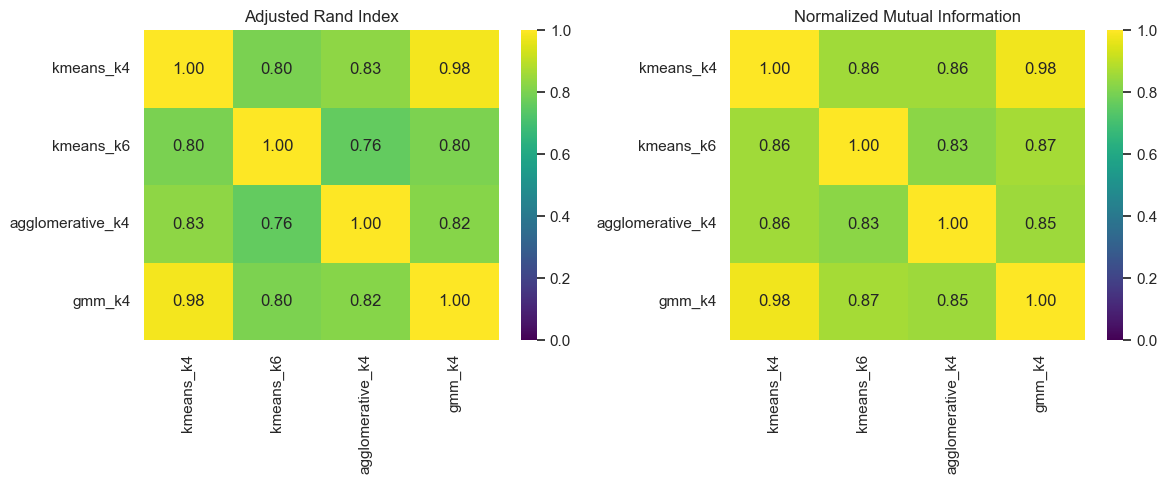

In [7]:
def aligned_labels(name_a: str, name_b: str) -> tuple[np.ndarray, np.ndarray]:
    subjects_a = runs[name_a]["metadata"]["subject_id"]
    subjects_b = runs[name_b]["metadata"]["subject_id"]
    if not subjects_a.equals(subjects_b):
        raise ValueError(
            f"{name_a!r} and {name_b!r} don't share the exact same subject_id order - align "
            "them explicitly (e.g. a merge on subject_id) before comparing labels positionally"
        )
    return runs[name_a]["labels"], runs[name_b]["labels"]


run_names = list(runs.keys())
ari_table = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
nmi_table = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
for name_a in run_names:
    for name_b in run_names:
        labels_a, labels_b = aligned_labels(name_a, name_b)
        ari_table.loc[name_a, name_b] = adjusted_rand_score(labels_a, labels_b)
        nmi_table.loc[name_a, name_b] = normalized_mutual_info_score(labels_a, labels_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(ari_table, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", ax=axes[0])
axes[0].set_title("Adjusted Rand Index")
sns.heatmap(nmi_table, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", ax=axes[1])
axes[1].set_title("Normalized Mutual Information")
fig.tight_layout()


## 4. Match matrix tra una coppia di run

Guardiamo da vicino `kmeans_k4` vs `agglomerative_k4`: stesso `k`, metodo diverso. È la
coppia più interessante da ispezionare a occhio, perché un eventuale disaccordo non si
spiega con un `k` sovra o sotto-specificato, ma riflette un vero disaccordo tra criteri di
raggruppamento.


,agglomerative_k4=0,agglomerative_k4=1,agglomerative_k4=2,agglomerative_k4=3
kmeans_k4=0,2,1,72,0
kmeans_k4=1,18,0,0,55
kmeans_k4=2,0,75,0,0
kmeans_k4=3,77,0,0,0


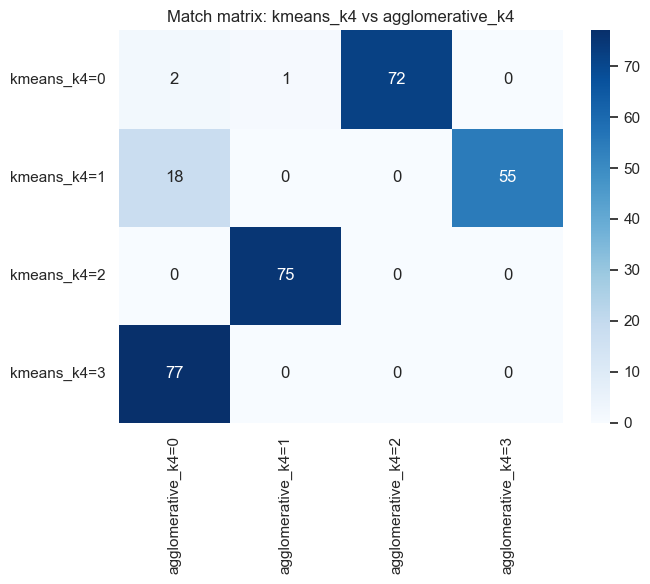

In [8]:
name_a, name_b = "kmeans_k4", "agglomerative_k4"
labels_a, labels_b = aligned_labels(name_a, name_b)
match_matrix = contingency_matrix(labels_a, labels_b)
match_df = pd.DataFrame(
    match_matrix,
    index=[f"{name_a}={c}" for c in sorted(np.unique(labels_a))],
    columns=[f"{name_b}={c}" for c in sorted(np.unique(labels_b))],
)

plt.figure(figsize=(7, 6))
sns.heatmap(match_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Match matrix: {name_a} vs {name_b}")
plt.yticks(rotation=0)
plt.tight_layout()
match_df


## 5. Subsampling Stability Index

Rifittiamo `kmeans_k4` e `agglomerative_k4` con gli stessi parametri (letti da
`config.md`, non ridichiarati a mano) su un campione all'80% dei soggetti, poi calcoliamo
l'ARI tra questo fit e quello sul 100% dei dati (`subsampling_stability_index` - un
confronto singolo, non un ensemble di ripetizioni come `run_monti_repeats`).

Un indice vicino a 1 indica che il clustering non dipende da un piccolo sottoinsieme di
soggetti; un valore basso è un segnale da approfondire prima di fidarsi della run, non un
motivo per scartarla automaticamente.


In [9]:
stability_rows = []
for name in ["kmeans_k4", "agglomerative_k4"]:
    run = runs[name]
    index = subsampling_stability_index(run["method"], run["X"], run["params"], subsample_fraction=0.8)
    stability_rows.append({"run": name, "subsampling_stability_index": index})

pd.DataFrame(stability_rows).set_index("run")


,subsampling_stability_index
run,
kmeans_k4,1.000000
agglomerative_k4,0.804316


## Riepilogo

Le metriche intrinseche (§2) si leggono solo dentro lo stesso metodo o la stessa scala -
non hanno senso per confrontare `kmeans` con `gmm` (AIC/BIC non sono comparabili con
Silhouette). ARI/NMI (§3) e la match matrix (§4) sono invece gli strumenti giusti per
confrontare run e metodi diversi tra loro. Il Subsampling Stability Index (§5) risponde a
una domanda ancora diversa: quella singola run è robusta al campione esatto di soggetti, o
è un artefatto?

Guida completa: `docs/guides/evaluation.md`.
